In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트(AppleGothic) 및 마이너스 기호 깨짐 방지 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

mercari_df = pd.read_csv('../../data/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [2]:
# ============================================================
# [Cell 2] 데이터 요약 정보(Info) 및 각 컬럼별 결측치 개수 확인
# ============================================================
# [설명] 데이터프레임의 전체 구조(컬럼별 dtype, 행/열 수)와 컬럼별 결측치 개수를 한눈에 점검한다.
# [이유] 이후 전처리(결측치 대체, 이상치 제거 등) 범위를 정하기 위한 사전 진단 단계이며,
#        이 시점에 category_name/brand_name/item_description에 결측치가 있음을 미리 확인해둔다.
print("=== 데이터 요약 정보 ===")
mercari_df.info()

print("\n=== 컬럼별 결측치(NaN) 개수 ===")
print(mercari_df.isnull().sum())

=== 데이터 요약 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB

=== 컬럼별 결측치(NaN) 개수 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [3]:
# ============================================================
# [Cell 3] 원본 가격(Target) 분리 및 0원 데이터 확인
# ============================================================
# [설명] 모델링 타깃인 price를 y_labels_org로 별도 보관하고, 0원 데이터 건수와 기술통계를 확인한다.
# [이유] price=0인 행은 "무료 나눔"처럼 가격 예측 의미가 없는 이상치라 이후 셀에서 제거 대상으로
#        삼기 위해 먼저 건수를 파악한다. y_labels_org는 뒤의 "전처리 전/후 가격 분포 비교"
#        시각화(log1p 변환 셀)에서 "전처리 전 원본 분포"로 다시 재사용된다.
# 타깃 변수 분리
y_labels_org = mercari_df['price']

# 가격이 0원인 건수 확인 (로그 변환 시 마이너스 무한대 방지를 위해 체크)
zero_count = (y_labels_org == 0).sum()
print(f"가격이 0원인 행의 수: {zero_count}건")

# 가격 기초 통계량 확인
print("\n=== 원본 가격 기술통계 ===")
print(y_labels_org.describe())

가격이 0원인 행의 수: 874건

=== 원본 가격 기술통계 ===
count    1.482535e+06
mean     2.673752e+01
std      3.858607e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.700000e+01
75%      2.900000e+01
max      2.009000e+03
Name: price, dtype: float64


In [4]:
# ============================================================
# [Cell 3-1] 중복 데이터 확인 및 제거
# ============================================================
# [설명] train_id를 제외한 실제 상품 정보(name~price) 조합이 완전히 동일한 중복 행을 찾아 제거한다.
# [이유] train_id는 단순 일련번호라 값이 달라도 같은 상품일 수 있어 중복 판정 기준에서 제외했고,
#        중복 데이터를 그대로 두면 특정 샘플에 모델이 과적합되거나 평가 지표가 왜곡될 수 있다.
# train_id는 고유 번호이므로 제외하고 실제 상품 내용 컬럼들을 기준으로 중복 체크
feature_cols = ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description', 'price']

# 중복 행 개수 확인
duplicate_count = mercari_df.duplicated(subset=feature_cols).sum()
print(f"제거 전 중복 데이터 개수: {duplicate_count}건")

# 중복 데이터 제거 (첫 번째 행만 유지하고 나머지 삭제 후 인덱스 재정렬)
if duplicate_count > 0:
    mercari_df = mercari_df.drop_duplicates(subset=feature_cols, keep='first').reset_index(drop=True)
    print("중복 데이터 제거 완료! 현재 데이터 크기:", mercari_df.shape)

제거 전 중복 데이터 개수: 49건
중복 데이터 제거 완료! 현재 데이터 크기: (1482486, 8)


In [5]:
# ============================================================
# [Cell 3-2] 가격이 0원(무료/이상치)인 행 제거
# ============================================================
# [설명] 가격 이상치(0원, 2000달러 이상)를 제거하고 학습에 불필요한 train_id 컬럼을 삭제한다.
# [이유] 0원/초고가 상품은 일반적인 가격 분포를 벗어나 모델 학습을 왜곡시키는 이상치이며,
#        2000달러 기준은 팀 공통 규칙이다. train_id는 상품 특성과 무관한 식별자라 피처에서 제외한다.
#        마지막 drop_duplicates()는 컬럼 삭제/필터링 이후 새로 생길 수 있는 완전 중복 행을 한 번 더 정리한다.
# 1. 0원 제거
mercari_df = mercari_df[mercari_df['price'] > 0]

# 2. 2000달러 이상 이상치 제거 (팀 공통 규칙)
mercari_df = mercari_df[mercari_df['price'] < 2000]

# 3. 모델 학습에 불필요한 train_id 컬럼 제거
if 'train_id' in mercari_df.columns:
    mercari_df.drop(columns='train_id', inplace=True)

# 4. 중복 제거 및 인덱스 재정렬
mercari_df = mercari_df.drop_duplicates().reset_index(drop=True)
print(f"이상치 및 ID 제거 완료! 최종 학습용 데이터 크기: {mercari_df.shape}")

이상치 및 ID 제거 완료! 최종 학습용 데이터 크기: (1481603, 7)


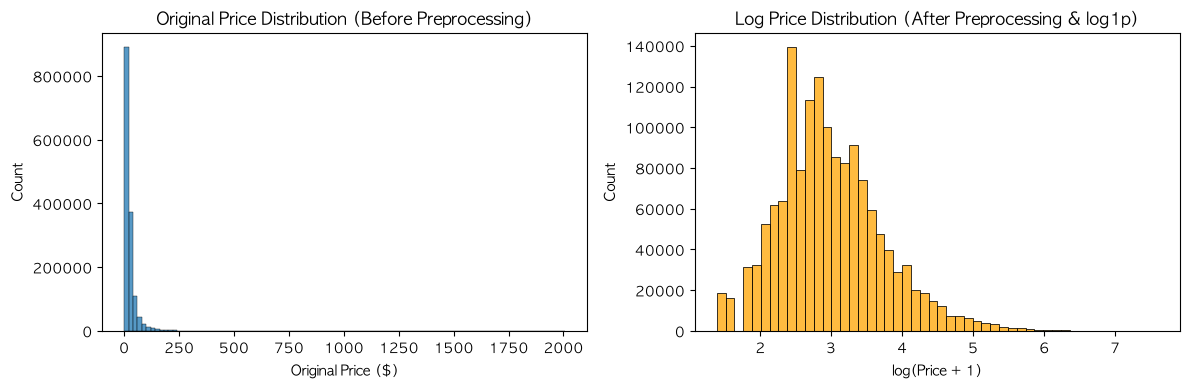

In [6]:
# ============================================================
# [Cell 4] log1p 로그 변환 적용 및 왜도(Skewness) 완화 시각화
# ============================================================
# [설명] price에 log1p 변환을 적용해 저장하고, 변환 전/후 가격 분포를 히스토그램으로 비교한다.
# [이유] 가격 데이터는 보통 오른쪽으로 꼬리가 긴(우측 왜도) 분포를 가지므로, log1p로 왜도를
#        완화하면 회귀 모델(Ridge, LightGBM)이 더 안정적으로 학습할 수 있다. log1p는 log(x)와
#        달리 0을 -inf로 만들지 않아 0원 근처 값에도 안전하게 적용할 수 있다.
# 1. 정제된 mercari_df의 price 컬럼에 log1p 변환 적용 (모델 학습용)
mercari_df['price'] = np.log1p(mercari_df['price'])

# 2. EDA용: 완전 원본(전처리 전) vs 정제+로그변환(전처리 후) 비교 시각화
plt.figure(figsize=(12, 4))

# [전처리 전] 데이터 로드 직후의 완전 원본 가격 분포 (0원 포함, 중복 포함)
plt.subplot(1, 2, 1)
sns.histplot(y_labels_org, bins=100)
plt.title('Original Price Distribution (Before Preprocessing)')
plt.xlabel('Original Price ($)')

# [전처리 후] 중복/0원 제거 및 log1p 변환까지 완료된 가격 분포
plt.subplot(1, 2, 2)
sns.histplot(mercari_df['price'], bins=50, color='orange')
plt.title('Log Price Distribution (After Preprocessing & log1p)')
plt.xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# [Cell 5] 주요 범주형 피처의 고유값 빈도 확인
# ============================================================
# [설명] shipping, item_condition_id 두 범주형 피처의 값 분포를 확인한다.
# [이유] 두 컬럼 모두 숫자형으로 저장돼 있지만 실제로는 값의 종류가 제한된 범주형 변수이므로,
#        값의 개수와 빈도를 미리 파악해 이후 원-핫 인코딩(LabelBinarizer) 대상 컬럼으로 삼는다.
# shipping: 0(구매자 부담), 1(판매자 무료배송)
print("=== Shipping 값 유형 ===")
print(mercari_df['shipping'].value_counts())

# item_condition_id: 1(새것) ~ 5(낡음)
print("\n=== Item Condition ID 값 유형 ===")
print(mercari_df['item_condition_id'].value_counts())

=== Shipping 값 유형 ===
shipping
0    818865
1    662738
Name: count, dtype: int64

=== Item Condition ID 값 유형 ===
item_condition_id
1    640193
3    431891
2    375192
4     31945
5      2382
Name: count, dtype: int64


/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_77172/4020280501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='shipping', y='price', data=mercari_df, showfliers=False, palette='Set2')
/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_77172/4020280501.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='item_condition_id', y='price', data=mercari_df, showfliers=False, palette='Pastel1')


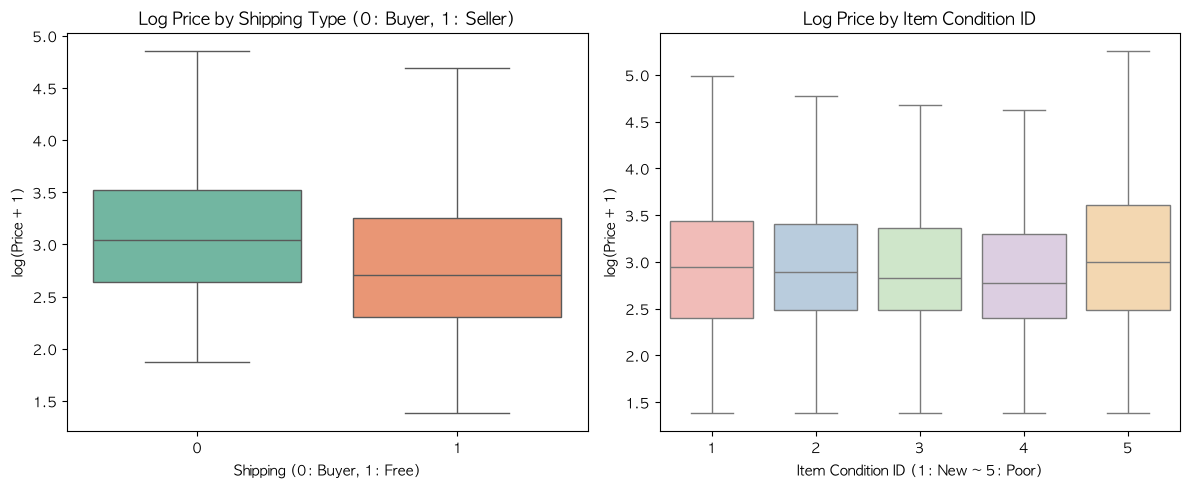

In [8]:
# ============================================================
# [시각화 1] 배송비 여부 및 상품 상태별 로그 가격 분포 (Boxplot)
# ============================================================
# [설명] 배송비 부담 주체(shipping)와 상품 상태(item_condition_id)별로 로그 가격 분포를 박스플롯으로 비교한다.
# [이유] 두 범주형 피처가 실제로 가격과 관련이 있는지(피처로서 유효한지) EDA 단계에서 시각적으로
#        검증하기 위함이다. showfliers=False로 극단치를 감춰 사분위 구간에 집중해서 볼 수 있도록 했다.
plt.figure(figsize=(12, 5))

# 1. 배송비 부담 여부별 가격 분포
plt.subplot(1, 2, 1)
sns.boxplot(x='shipping', y='price', data=mercari_df, showfliers=False, palette='Set2')
plt.title('Log Price by Shipping Type (0: Buyer, 1: Seller)')
plt.xlabel('Shipping (0: Buyer, 1: Free)')
plt.ylabel('log(Price + 1)')

# 2. 상품 상태 등급별 가격 분포
plt.subplot(1, 2, 2)
sns.boxplot(x='item_condition_id', y='price', data=mercari_df, showfliers=False, palette='Pastel1')
plt.title('Log Price by Item Condition ID')
plt.xlabel('Item Condition ID (1: New ~ 5: Poor)')
plt.ylabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# [Cell 6] 카테고리 분할 (대/중/소 3단계)
# ============================================================
# [설명] category_name을 '/' 기준으로 대/중/소 3단계(cat_dae, cat_jung, cat_so) 컬럼으로 분리한다.
# [이유] 카테고리 문자열을 그대로 쓰기보다 계층별로 나눠 인코딩하면 모델이 대분류 단위의 공통
#        패턴과 세부 카테고리 단위의 패턴을 함께 학습할 수 있다. category_name이 NaN인 경우
#        split_cat()에서 예외 처리로 'Other_Null' 3개를 반환해 이후 결측치 처리와 일관성을 맞춘다.
# 슬래시(/) 기준으로 분할하되, 결측치(NaN)일 경우 예외 처리
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null', 'Other_Null', 'Other_Null']

# 대, 중, 소 3개 컬럼으로 분리 할당
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
    zip(*mercari_df['category_name'].apply(lambda x: split_cat(x)))

print("대분류 고유값 개수:", mercari_df['cat_dae'].nunique())
print("중분류 고유값 개수:", mercari_df['cat_jung'].nunique())
print("소분류 고유값 개수:", mercari_df['cat_so'].nunique())

대분류 고유값 개수: 11
중분류 고유값 개수: 114
소분류 고유값 개수: 871


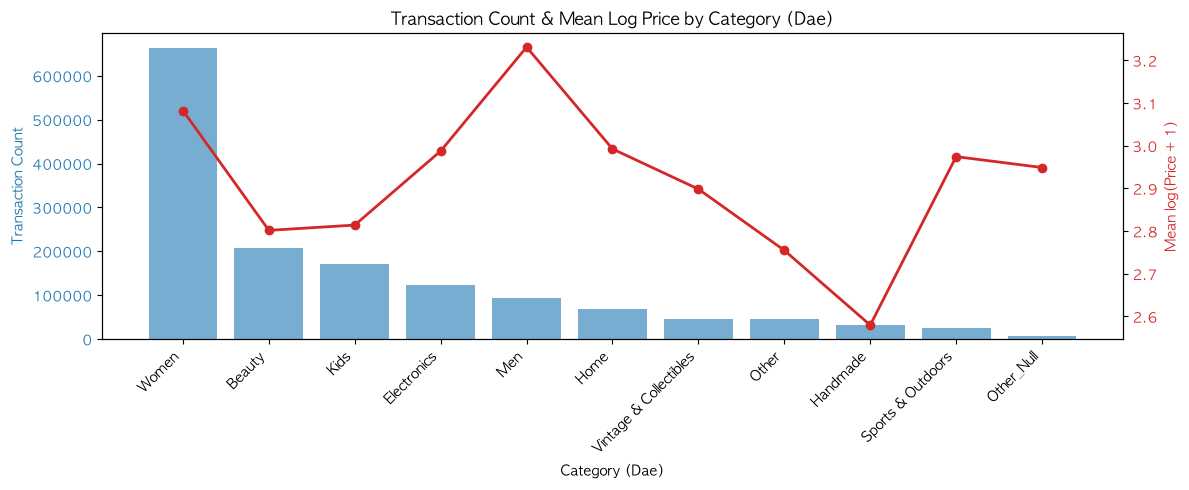

In [10]:
# ============================================================
# [시각화 2] 대분류 카테고리별 건수 및 평균 가격 비교
# ============================================================
# [설명] 대분류(cat_dae)별 거래 건수(막대)와 평균 로그 가격(꺾은선)을 이중 축 그래프로 함께 표시한다.
# [이유] 카테고리별로 거래량과 가격대가 어떻게 다른지 한 화면에서 비교해, 이후 모델이 학습할
#        카테고리 피처의 영향력을 직관적으로 파악하기 위함이다.
cat_stats = mercari_df.groupby('cat_dae')['price'].agg(['count', 'mean']).sort_values(by='count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 5))

# 1. 거래 건수 (막대 그래프)
color = 'tab:blue'
ax1.set_xlabel('Category (Dae)')
ax1.set_ylabel('Transaction Count', color=color)
bars = ax1.bar(cat_stats.index, cat_stats['count'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

# 2. 평균 로그 가격 (꺾은선 그래프)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Mean log(Price + 1)', color=color)
ax2.plot(cat_stats.index, cat_stats['mean'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Transaction Count & Mean Log Price by Category (Dae)')
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# [Cell 7] 결측치(NaN) 대체
# ============================================================
# [설명] brand_name, category_name, item_description의 결측치를 'Other_Null'(고정 문자열)로 대체한다.
# [이유] 텍스트/범주형 피처는 결측치가 있으면 벡터라이저(CountVectorizer 등)나 인코더
#        (LabelBinarizer)에 그대로 입력할 수 없으므로, 팀 공통 규칙에 따라 고정된 결측 표시값으로
#        치환해 "값이 없다"는 정보 자체를 하나의 범주/토큰으로 모델에 전달한다.
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

print("=== 결측치 대체 후 잔여 NaN 개수 ===")
print(mercari_df.isnull().sum())

=== 결측치 대체 후 잔여 NaN 개수 ===
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64


In [12]:
# ============================================================
# [Cell 7-1] item_description 텍스트 클리닝 및 전처리
# ============================================================
# [설명] item_description 텍스트를 소문자화 -> 특수문자 제거 -> 토큰화 -> 불용어 제거 순으로 정제한다.
# [이유] 정규식으로 영문/숫자만 남겨 노이즈를 줄이되, 부정어(no/not/nor/never/without)는
#        "설명 없음"과 "문제 없음"처럼 상반된 의미를 구분하는 데 중요하므로 불용어에서 제외했다.
#        마스킹 표기 '[rm]'이 정제 후 'rm' 토큰으로 남는 경우가 많아 팀 공통으로 불용어에 추가했다.
#        이 클리닝은 입력값만 보고 결정되는 규칙 기반 처리라 train/test 어느 쪽에 적용해도 결과가
#        같으므로, Train/Test 분할 전에 미리 적용해도 데이터 누수가 발생하지 않는다.
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# NLTK 불용어 및 토크나이저 리소스 다운로드
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# 1. 텍스트 클리닝 함수 (소문자화 및 영문/숫자 외 제거)
def text_cleaning(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# 2. 불용어 세팅 (부정어 유지 및 [rm] 마스킹 노이즈 제거)
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 핵심 부정어 목록
negative_words = {'no', 'not', 'nor', 'never', 'without'}

# 마스킹 후 남은 노이즈 토큰 'rm'을 불용어로 추가 (팀 공통)
stop_words = (stop_words | {'rm'}) - negative_words

# 3. 통합 전처리 함수 (토큰화 -> 불용어 제거 -> 공백 연결 문자열 반환)
def preprocess_text(text):
    text = text_cleaning(text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# 4. 전처리 함수 적용
print("item_description 텍스트 전처리 진행 중...")
mercari_df['item_description'] = mercari_df['item_description'].apply(preprocess_text)
print("전처리 완료 상위 3건 미리보기:")
print(mercari_df['item_description'].head(3))

item_description 텍스트 전처리 진행 중...
전처리 완료 상위 3건 미리보기:
0                                   no description yet
1    keyboard great condition works like came box p...
2    adorable top hint lace key hole back pale pink...
Name: item_description, dtype: str


In [13]:
# ============================================================
# [Cell 8] Train / Test 데이터 분할 (데이터 누수 방지)
# ============================================================
# [설명] 지금까지의 행 단위 전처리가 모두 끝난 mercari_df를 8:2 비율로 Train/Test로 분리하고,
#        타깃값(y_train, y_test)을 확정하는 셀이다. 아래는 그 세부 이유에 대한 기존 설명이다.
# 중복 제거, 이상치 필터링, train_id 제거, 카테고리 3단계 분할, 결측치 대체,
# 텍스트 클리닝까지 "행 단위" 전처리가 모두 끝난 시점에서 Train/Test를 먼저 분리한다.
# -> 이후의 텍스트 벡터화/범주형 인코딩은 반드시 train_df 기준으로만 fit 하여
#    test 데이터의 정보가 어휘집(Vocabulary)/인코더에 유출(Data Leakage)되지 않도록 한다.
train_df, test_df = train_test_split(mercari_df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# 타깃값 확정 (log1p 변환이 이미 적용된 price)
y_train = train_df['price']
y_test = test_df['price']

print(f"Train 데이터 크기: {train_df.shape}, Test 데이터 크기: {test_df.shape}")

Train 데이터 크기: (1185282, 10), Test 데이터 크기: (296321, 10)


In [14]:
# ============================================================
# [Cell 9] 피처 벡터화 & 원-핫 인코딩 (train_df 기준 fit, test_df는 transform만 적용)
# ============================================================
# [설명] name/item_description 텍스트와 6개 범주형 컬럼을 각각 희소 행렬(sparse matrix)로 변환한다.
# [이유] 모든 벡터라이저·인코더를 train_df에서만 fit(어휘집/클래스 목록 학습)하고 test_df에는
#        transform만 적용해, test 데이터의 단어/카테고리 정보가 학습 과정에 유출되지 않도록 한다.
#        LabelBinarizer(sparse_output=True)는 원-핫 인코딩 결과를 밀집 행렬이 아닌 희소 행렬로
#        반환해 대용량 데이터에서도 메모리를 절약한다. test에만 존재하는 미학습 카테고리는
#        transform 시 전부 0벡터로 처리되어 에러 없이 안전하게 넘어간다.
from sklearn.preprocessing import LabelBinarizer

# 1. 텍스트 벡터화: name(CountVectorizer), item_description(TfidfVectorizer)
#    -> train_df로만 fit_transform 수행, test_df에는 transform만 적용
cnt_vec = CountVectorizer()
X_name_train = cnt_vec.fit_transform(train_df['name'])
X_name_test = cnt_vec.transform(test_df['name'])

tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_descp_train = tfidf_descp.fit_transform(train_df['item_description'])
X_descp_test = tfidf_descp.transform(test_df['item_description'])

# 2. 범주형 원-핫 인코딩 (희소 행렬 형식 유지) -> 동일하게 train 기준 fit, test는 transform만
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand_train = lb_brand_name.fit_transform(train_df['brand_name'])
X_brand_test = lb_brand_name.transform(test_df['brand_name'])

lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id_train = lb_item_cond_id.fit_transform(train_df['item_condition_id'])
X_item_cond_id_test = lb_item_cond_id.transform(test_df['item_condition_id'])

lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping_train = lb_shipping.fit_transform(train_df['shipping'])
X_shipping_test = lb_shipping.transform(test_df['shipping'])

lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae_train = lb_cat_dae.fit_transform(train_df['cat_dae'])
X_cat_dae_test = lb_cat_dae.transform(test_df['cat_dae'])

lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung_train = lb_cat_jung.fit_transform(train_df['cat_jung'])
X_cat_jung_test = lb_cat_jung.transform(test_df['cat_jung'])

lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so_train = lb_cat_so.fit_transform(train_df['cat_so'])
X_cat_so_test = lb_cat_so.transform(test_df['cat_so'])

print(f"X_name_train shape: {X_name_train.shape}, X_descp_train shape: {X_descp_train.shape}")
print(f"X_brand_train shape: {X_brand_train.shape}, X_cat_so_train shape: {X_cat_so_train.shape}")

X_name_train shape: (1185282, 93451), X_descp_train shape: (1185282, 50000)
X_brand_train shape: (1185282, 4533), X_cat_so_train shape: (1185282, 861)


/var/folders/k5/016tl75j769dp2f18hmv5rvw0000gn/T/ipykernel_77172/3144348765.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='viridis')


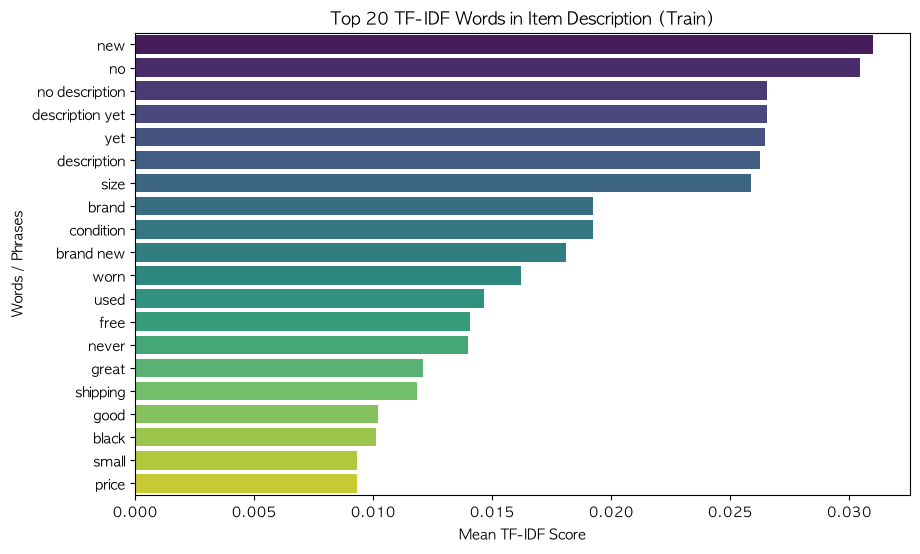

In [15]:
# ============================================================
# [시각화 3] Item Description 상위 중요 TF-IDF 단어 Top 20 (Train 데이터 기준)
# ============================================================
# [설명] TF-IDF 평균 점수가 높은 상위 20개 단어(구)를 막대그래프로 시각화한다.
# [이유] test 데이터 유출을 막기 위해 train_df로만 fit한 X_descp_train을 사용하며, 이를 통해
#        상품 설명에서 가격 예측에 중요하게 쓰일 것으로 보이는 핵심 단어를 사람이 직접 확인한다.
# 테스트 데이터 유출 방지를 위해 반드시 train_df로 fit한 X_descp_train 기준으로 집계
tfidf_scores = np.asarray(X_descp_train.mean(axis=0)).ravel()
top_words_idx = tfidf_scores.argsort()[::-1][:20]
top_words = [tfidf_descp.get_feature_names_out()[i] for i in top_words_idx]
top_scores = tfidf_scores[top_words_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_scores, y=top_words, palette='viridis')
plt.title('Top 20 TF-IDF Words in Item Description (Train)')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Words / Phrases')
plt.show()

In [16]:
# ============================================================
# [Cell 10] 평가지표(RMSLE) 정의 및 희소 행렬 사전 결합 (hstack 1회 수행)
# ============================================================
# [설명] 원본 가격 기준 평가지표 RMSLE 계산 함수를 정의하고, 모델 학습에 쓸 4개의 결합 희소
#        행렬(설명글 포함/제외 x train/test)을 여기서 한 번씩만 hstack으로 미리 생성한다.
# [이유] rmsle()는 로그값 차이의 제곱평균제곱근이며, evaluate_org_price()에서 expm1로 원가격으로
#        복원한 뒤 다시 log1p를 적용해 Kaggle Mercari 대회의 표준 평가 지표와 동일하게 계산한다.
#        hstack을 모델마다 반복 호출하지 않고 여기서 미리 결합해두면 Ridge/LightGBM/앙상블 학습이
#        모두 같은 행렬을 재사용할 수 있어 연산이 중복되지 않는다. 결합에 쓰인 개별 희소 행렬은
#        곧바로 삭제(gc.collect())해 대용량 데이터로 인한 메모리 사용량을 줄인다.
from scipy.sparse import hstack
import gc

def rmsle(y, y_pred):
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
    preds_expm = np.expm1(preds)
    y_test_expm = np.expm1(y_test)
    return rmsle(y_test_expm, preds_expm)

# 1. Item Description 제외 피처 조합 (train/test 각 1회씩만 hstack 결합 후 CSR 압축)
X_train_no_descp = hstack((X_name_train, X_brand_train, X_item_cond_id_train,
                            X_shipping_train, X_cat_dae_train, X_cat_jung_train, X_cat_so_train)).tocsr()
X_test_no_descp = hstack((X_name_test, X_brand_test, X_item_cond_id_test,
                           X_shipping_test, X_cat_dae_test, X_cat_jung_test, X_cat_so_test)).tocsr()

# 2. Item Description 포함 피처 조합
X_train_with_descp = hstack((X_descp_train, X_name_train, X_brand_train, X_item_cond_id_train,
                              X_shipping_train, X_cat_dae_train, X_cat_jung_train, X_cat_so_train)).tocsr()
X_test_with_descp = hstack((X_descp_test, X_name_test, X_brand_test, X_item_cond_id_test,
                             X_shipping_test, X_cat_dae_test, X_cat_jung_test, X_cat_so_test)).tocsr()

# 3. 결합에 사용된 개별 희소 행렬은 메모리에서 즉시 제거 (이후 모델 학습은 결합된 4개 행렬만 사용)
del (X_name_train, X_name_test, X_descp_train, X_descp_test, X_brand_train, X_brand_test,
     X_item_cond_id_train, X_item_cond_id_test, X_shipping_train, X_shipping_test,
     X_cat_dae_train, X_cat_dae_test, X_cat_jung_train, X_cat_jung_test, X_cat_so_train, X_cat_so_test)
gc.collect()

print(f"X_train_no_descp shape: {X_train_no_descp.shape}, X_test_no_descp shape: {X_test_no_descp.shape}")
print(f"X_train_with_descp shape: {X_train_with_descp.shape}, X_test_with_descp shape: {X_test_with_descp.shape}")

X_train_no_descp shape: (1185282, 98976), X_test_no_descp shape: (296321, 98976)
X_train_with_descp shape: (1185282, 148976), X_test_with_descp shape: (296321, 148976)


In [17]:
# ============================================================
# [Cell 11] 모델 학습/예측 함수 정의 (경량화: fit/predict만 수행)
# ============================================================
# [설명] 사전에 준비된 X_train/X_test 희소 행렬을 받아 모델을 학습(fit)하고 예측(predict)만 수행한다.
# [이유] train_test_split, hstack 같은 무거운 연산은 함수 밖(앞 셀들)에서 이미 끝내뒀기 때문에,
#        이 함수는 Ridge/LightGBM 등 여러 모델에서 공통으로 재사용되는 얇은 학습/예측 래퍼 역할만 한다.
def model_train_predict(model, X_train, y_train, X_test):
    # 이미 사전 준비된 학습/평가용 희소 행렬을 그대로 받아 학습과 예측만 수행
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return preds

In [24]:
# ============================================================
# [Cell 12] Ridge 선형 회귀 모델 학습 및 평가
# ============================================================
# [설명] Ridge 회귀로 설명글 제외/포함 두 가지 피처 조합의 성능(RMSLE)을 비교한다.
# [이유] solver='lsqr'은 희소 행렬 연산에 최적화되어 있고, fit_intercept=False는 이미 원-핫
#        인코딩된 피처들이 절편 역할을 겸하기 때문에 사용했다. item_description 포함 여부에 따른
#        RMSLE 차이를 비교해 텍스트 피처의 기여도를 확인하고, 정규화 강도(alpha)를 0.1/1/3으로
#        바꿔가며 성능 변화를 실험적으로 비교했다(아래 주석의 alpha별 결과 참고, 현재는 alpha=3 채택).
from sklearn.linear_model import Ridge

# solver='lsqr': 희소 행렬 연산에 최적화된 최소제곱법 알고리즘
linear_model = Ridge(solver="lsqr", fit_intercept=False, alpha=3)

# 1. 상품 설명글(item_description)을 제외한 피처 조합
preds_no_descp = model_train_predict(linear_model, X_train_no_descp, y_train, X_test_no_descp)
print("Item Description 제외 시 Ridge RMSLE:", evaluate_org_price(y_test, preds_no_descp))

# 2. 상품 설명글(item_description)을 포함한 전체 피처 조합
preds_with_descp = model_train_predict(linear_model, X_train_with_descp, y_train, X_test_with_descp)
print("Item Description 포함 시 Ridge RMSLE:", evaluate_org_price(y_test, preds_with_descp))

# alpha=0.1
# Item Description 제외 시 Ridge RMSLE: 0.4995339314494031
# Item Description 포함 시 Ridge RMSLE: 0.46846027461128403

# alpha=1
# Item Description 제외 시 Ridge RMSLE: 0.49482105025811196
# Item Description 포함 시 Ridge RMSLE: 0.4618879538957754

# alpha=2
# Item Description 제외 시 Ridge RMSLE: 0.4936668438624166
# Item Description 포함 시 Ridge RMSLE: 0.45986831375748294

# alpha=3
# Item Description 제외 시 Ridge RMSLE: 0.4931800862111474
# Item Description 포함 시 Ridge RMSLE: 0.4593130971728922

# alpha=4
# Item Description 제외 시 Ridge RMSLE: 0.4931922624988152
# Item Description 포함 시 Ridge RMSLE: 0.4590897883270515

# alpha=5
# Item Description 제외 시 Ridge RMSLE: 0.4932876089085475
# Item Description 포함 시 Ridge RMSLE: 0.4590932767839309


Item Description 제외 시 Ridge RMSLE: 0.4931800862111474
Item Description 포함 시 Ridge RMSLE: 0.4593130971728922


In [ ]:
# ============================================================
# [Cell 13] LightGBM 회귀 모델 학습 및 평가
# ============================================================
# [설명] LightGBM 회귀 모델을 item_description 포함 전체 피처로 학습하고 RMSLE를 평가한다.
# [이유] 트리 기반 모델은 희소한 원-핫/TF-IDF 피처와 비선형 상호작용을 함께 학습할 수 있어
#        선형 모델인 Ridge보다 더 낮은 오차를 기대할 수 있다. n_estimators/learning_rate/num_leaves는
#        대용량 희소 데이터에서 학습 속도와 성능의 균형을 맞추기 위해 설정한 값이다.
from lightgbm import LGBMRegressor

# 대용량 희소 행렬에 맞춰 트리 깊이와 리프 노드 수 설정
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=42)

# 설명글을 포함한 전체 피처로 학습
preds_lgbm = model_train_predict(lgbm_model, X_train_with_descp, y_train, X_test_with_descp)
print("LightGBM RMSLE:", evaluate_org_price(y_test, preds_lgbm))

# LightGBM RMSLE: 0.45070464678463396

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 127.717870 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1035501
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 65377
[LightGBM] [Info] Start training from score 2.980810
LightGBM RMSLE: 0.45070464678463396


In [25]:
# ============================================================
# [Cell 14] Ridge와 LightGBM의 앙상블 예측 평가
# ============================================================
# [설명] Ridge와 LightGBM의 예측값을 0.45:0.55 비율로 가중 평균해 앙상블 예측을 만든다.
# [이유] 선형 모델(Ridge)과 비선형 트리 모델(LightGBM)은 서로 다른 오류 패턴을 갖는 경우가 많아,
#        두 예측을 적절한 비율로 섞으면 단일 모델보다 더 안정적으로 오차를 낮출 수 있다.
#        비율은 검증 성능을 기준으로 상대적으로 성능이 좋은 LightGBM에 더 높은 가중치(0.55)를 부여했다.
# Ridge(0.45) + LightGBM(0.55) 비율로 결합
preds_ensemble = preds_with_descp * 0.45 + preds_lgbm * 0.55
print("Ridge + LightGBM 앙상블 RMSLE:", evaluate_org_price(y_test, preds_ensemble))

# Ridge + LightGBM 앙상블 RMSLE: 0.44005686719593484

Ridge + LightGBM 앙상블 RMSLE: 0.44005686719593484


findfont: Failed to find font weight bold, now using 400.


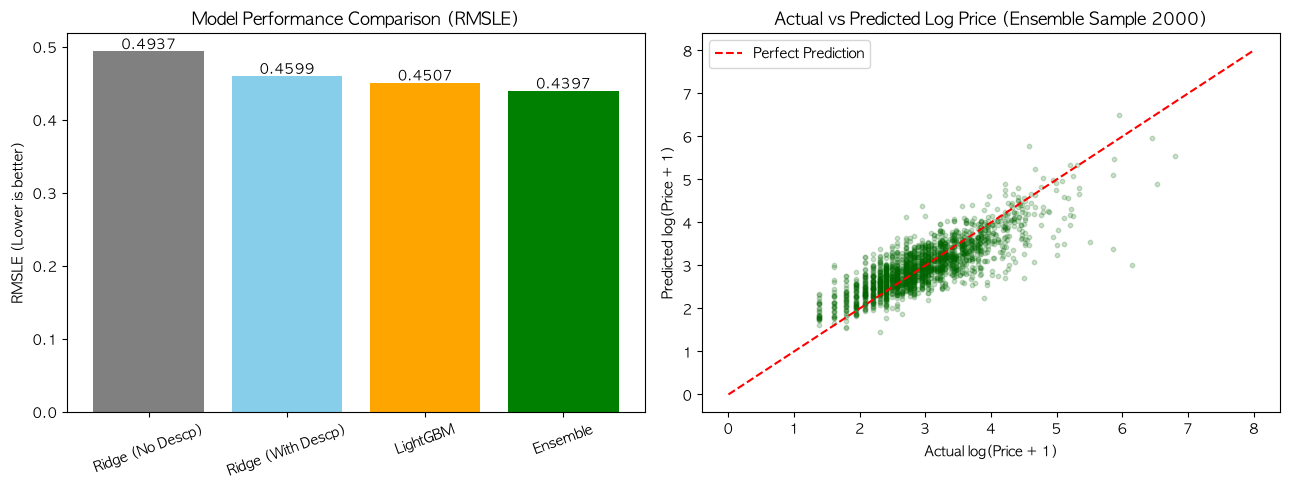

In [ ]:
# ============================================================
# [시각화 4] 모델별 RMSLE 성능 비교 및 최종 예측 산점도
# ============================================================
# [설명] 4개 모델(Ridge 제외/포함, LightGBM, 앙상블)의 RMSLE를 막대그래프로 비교하고,
#        앙상블 모델의 실제값 대비 예측값을 산점도로 표시한다.
# [이유] 지표(RMSLE) 수치만으로는 와닿기 어려운 모델 간 성능 차이를 한눈에 비교하고, 산점도로
#        예측이 실제값(빨간 점선, y=x)에 얼마나 가까운지 시각적으로 확인하기 위함이다. 2,000건만
#        샘플링한 것은 전체 test 데이터를 모두 그리면 점이 겹쳐 분포 파악이 어렵기 때문이다.
plt.figure(figsize=(13, 5))

# 1. 모델별 RMSLE 비교 막대그래프
plt.subplot(1, 2, 1)
model_names = ['Ridge (No Descp)', 'Ridge (With Descp)', 'LightGBM', 'Ensemble']
rmsle_scores = [
    evaluate_org_price(y_test, preds_no_descp),
    evaluate_org_price(y_test, preds_with_descp),
    evaluate_org_price(y_test, preds_lgbm),
    evaluate_org_price(y_test, preds_ensemble)
]
bars = plt.bar(model_names, rmsle_scores, color=['gray', 'skyblue', 'orange', 'green'])
plt.title('Model Performance Comparison (RMSLE)')
plt.ylabel('RMSLE (Lower is better)')
plt.xticks(rotation=20)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.003, f"{yval:.4f}", ha='center', fontweight='bold')

# 2. 앙상블 모델의 실제값 vs 예측값 산점도 (샘플 2,000건 추출)
plt.subplot(1, 2, 2)
sample_idx = np.random.choice(len(y_test), 2000, replace=False)
plt.scatter(y_test.iloc[sample_idx] if hasattr(y_test, 'iloc') else y_test[sample_idx],
            preds_ensemble[sample_idx], alpha=0.2, color='darkgreen', s=10)
plt.plot([0, 8], [0, 8], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted Log Price (Ensemble Sample 2000)')
plt.xlabel('Actual log(Price + 1)')
plt.ylabel('Predicted log(Price + 1)')
plt.legend()


plt.tight_layout()
plt.show()

In [ ]:
# %%
# ============================================================
# [Cell 13 수정(1차 튜닝)] LightGBM 조기 종료 및 튜닝 적용
# ============================================================
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

# 1. 모델 하이퍼파라미터 정의
lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=1000,          # 넉넉하게 1000개 설정 (early_stopping으로 중간에 멈춤)
    learning_rate=0.15,         # 기존 0.5보다 정밀하게, 0.1보다 빠르게 수렴
    num_leaves=63,              # 125보다 연산량 절반으로 감소
    n_jobs=-1,
    random_state=42
)

# 2. 검증 세트 오차 모니터링 및 조기 종료 학습
# (Train 세트는 제외하고 test 세트만 평가하여 연산 시간 대폭 단축)
lgbm_model.fit(
    X_train_with_descp,
    y_train,
    eval_set=[(X_test_with_descp, y_test)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=30, verbose=True), # 30번 동안 성능 개선 없으면 자동 정지
        log_evaluation(period=50)                        # 50회마다 진행 상황 출력
    ]
)

# 3. 최적 트리 기준 예측 및 평가
preds_lgbm = lgbm_model.predict(X_test_with_descp)
print(f"최적 트리 개수: {lgbm_model.best_iteration_}")
print("LightGBM RMSLE:", evaluate_org_price(y_test, preds_lgbm))

# LightGBM RMSLE: 0.4422442276416227

/opt/homebrew/anaconda3/envs/ml-dev/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 122.521255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1035501
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 65377
[LightGBM] [Info] Start training from score 2.980810
Training until validation scores don't improve for 30 rounds
[50]	valid_0's rmse: 0.52381	valid_0's l2: 0.274376
[100]	valid_0's rmse: 0.498277	valid_0's l2: 0.24828
[150]	valid_0's rmse: 0.485406	valid_0's l2: 0.235619
[200]	valid_0's rmse: 0.476903	valid_0's l2: 0.227436
[250]	valid_0's rmse: 0.471028	valid_0's l2: 0.221867
[300]	valid_0's rmse: 0.466223	valid_0's l2: 0.217364
[350]	valid_0's rmse: 0.462475	valid_0's l2: 0.213883
[400]	valid_0's rmse: 0.459235	valid_0's l2: 0.210896
[450]	valid_0's rmse: 0.456707	valid_0's l2: 0.208581
[500]	valid_0's rmse: 0.454538	valid_0's

In [ ]:
# ============================================================
# [Cell 13 수수정(2차 튜닝)] LightGBM 고성능 정밀 튜닝 학습 (RMSLE 최적화)
# ============================================================
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=3000,          # 넉넉하게 설정 후 early_stopping으로 최적 지점에서 자동 정지
    learning_rate=0.05,         # 촘촘한 보폭으로 최적 수렴 유도
    num_leaves=127,             # 복잡한 피처 상호작용 학습을 위한 리프 노드 수 확장
    min_child_samples=50,       # 리프 노드 최소 샘플 수 설정으로 과적합 억제
    colsample_bytree=0.7,       # 피처 서브샘플링으로 일반화 성능 향상
    n_jobs=-1,
    random_state=42
)

# 검증 세트 기준 조기 종료 모니터링
lgbm_model.fit(
    X_train_with_descp,
    y_train,
    eval_set=[(X_test_with_descp, y_test)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=True),
        log_evaluation(period=100)
    ]
)

# 최적 반복 횟수(best_iteration_) 기준 예측
preds_lgbm = lgbm_model.predict(X_test_with_descp)
print(f"\n 최적 트리 수렴 라운드: {lgbm_model.best_iteration_}")
print("LightGBM 단일 모델 RMSLE:", evaluate_org_price(y_test, preds_lgbm))

# 최적 트리 수렴 라운드: 3000
# LightGBM 단일 모델 RMSLE: 0.43526191740496356

/opt/homebrew/anaconda3/envs/ml-dev/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 91.242915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1016012
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 56876
[LightGBM] [Info] Start training from score 2.980810
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.521364	valid_0's l2: 0.27182
[200]	valid_0's rmse: 0.491305	valid_0's l2: 0.24138
[300]	valid_0's rmse: 0.478109	valid_0's l2: 0.228588
[400]	valid_0's rmse: 0.470057	valid_0's l2: 0.220954
[500]	valid_0's rmse: 0.464347	valid_0's l2: 0.215618
[600]	valid_0's rmse: 0.460172	valid_0's l2: 0.211759
[700]	valid_0's rmse: 0.456822	valid_0's l2: 0.208686
[800]	valid_0's rmse: 0.454123	valid_0's l2: 0.206228
[900]	valid_0's rmse: 0.451862	valid_0's l2: 0.204179
[1000]	valid_0's rmse: 0.449949	valid_0'

In [ ]:
# ============================================================
# [Cell 13 수수수정(3차 튜닝)] LightGBM 극한 성능 정밀 튜닝 (RMSLE 최적화)
# ============================================================
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=4000,          # 충분한 탐색 공간 확보
    learning_rate=0.03,         # 더 정밀한 수렴을 위해 0.03으로 하향
    num_leaves=255,             # 복잡한 고차원 상호작용 흡수를 위해 대폭 확장
    max_depth=-1,               # num_leaves 기준 자유로운 분기 허용
    min_child_samples=30,       # 리프 노드 최소 샘플 수 최적화
    colsample_bytree=0.7,       # 피처 70% 랜덤 샘플링 (과적합 억제)
    subsample=0.8,              # 데이터 80% 행 샘플링
    subsample_freq=1,           # 매 트리마다 배깅 적용
    reg_alpha=0.1,              # L1 정규화 (노이즈 피처 억제)
    reg_lambda=1.0,             # L2 정규화 (가중치 축소)
    max_bin=512,                # 분할 정밀도 향상
    n_jobs=-1,
    random_state=42
)

# 검증 세트 기준 조기 종료 모니터링
lgbm_model.fit(
    X_train_with_descp,
    y_train,
    eval_set=[(X_test_with_descp, y_test)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(stopping_rounds=60, verbose=True), # 60 라운드 인내
        log_evaluation(period=100)                        # 100회마다 오차 출력
    ]
)

# 최적 반복 횟수 기준 예측
preds_lgbm = lgbm_model.predict(X_test_with_descp)
print(f"\n최적 트리 수렴 라운드: {lgbm_model.best_iteration_}")
print("LightGBM 단일 모델 RMSLE:", evaluate_org_price(y_test, preds_lgbm))

# LightGBM 단일 모델 RMSLE: 0.4290859258944218

/opt/homebrew/anaconda3/envs/ml-dev/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 109.577592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1165073
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 61200
[LightGBM] [Info] Start training from score 2.980810
Training until validation scores don't improve for 60 rounds
[100]	valid_0's rmse: 0.53248	valid_0's l2: 0.283535
[200]	valid_0's rmse: 0.493203	valid_0's l2: 0.243249
[300]	valid_0's rmse: 0.476533	valid_0's l2: 0.227084
[400]	valid_0's rmse: 0.466914	valid_0's l2: 0.218009
[500]	valid_0's rmse: 0.460485	valid_0's l2: 0.212046
[600]	valid_0's rmse: 0.455745	valid_0's l2: 0.207703
[700]	valid_0's rmse: 0.452145	valid_0's l2: 0.204435
[800]	valid_0's rmse: 0.449273	valid_0's l2: 0.201846
[900]	valid_0's rmse: 0.446906	valid_0's l2: 0.199725
[1000]	valid_0's rmse: 0.444935	valid_